# Machine Learning Models

This notebook trains and evaluates multiple classical machine learning models for multi-cancer transcriptomic classification.

Models implemented:

- Logistic Regression
- Random Forest
- Support Vector Machine (Linear Kernel)

Each model is evaluated using:

- Classification Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training Time

In [1]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Processed Dataset

In [3]:
feature_df = pd.read_csv(
    "../data/processed/final_feature_dataset.csv"
)

label_df = pd.read_csv(
    "../data/raw/labels.csv"
)

In [7]:
X = feature_df

y = label_df["Class"]

In [8]:
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (801, 250)
Label vector shape: (801,)


,gene_18,gene_30,gene_89,gene_145,gene_148,gene_180,gene_203,gene_219,gene_220,gene_223,...,gene_18676,gene_18745,gene_18746,gene_19151,gene_19153,gene_19159,gene_19201,gene_19236,gene_19373,gene_19914
0,0.591871,0.0,13.230181,8.126338,9.920593,0.000000,15.673080,0.591871,0.591871,3.188164,...,0.000000,11.263070,7.689285,4.975438,1.010279,1.598651,1.822037,0.591871,0.000000,11.919474
1,0.000000,0.0,8.885272,7.036613,4.256241,1.813607,9.184930,0.000000,0.000000,3.651924,...,0.000000,1.813607,8.292989,5.174742,0.000000,0.323658,1.327170,0.811142,0.811142,4.095722
2,1.683023,0.0,13.892087,9.938817,11.209130,0.000000,13.804736,0.000000,0.452595,0.452595,...,0.000000,8.956010,10.833428,0.000000,0.000000,0.000000,1.507160,0.796598,1.981122,9.526732
3,1.267356,0.0,14.982962,8.302831,10.286327,0.000000,17.472493,1.039419,0.434882,2.728704,...,1.267356,14.135228,9.562801,0.000000,0.768587,1.791814,1.267356,1.267356,0.768587,11.807347
4,0.889707,0.0,6.477750,7.908681,1.095654,3.525831,4.056150,0.000000,0.000000,1.580097,...,0.000000,2.967630,14.439409,0.000000,0.000000,0.360982,2.858777,0.000000,0.000000,11.542147


0    PRAD
1    LUAD
2    PRAD
3    PRAD
4    BRCA
Name: Class, dtype: object

In [6]:
print(label_df.head())

print("\nColumns:")
print(label_df.columns)

print("\nShape:")
print(label_df.shape)

  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA

Columns:
Index(['Unnamed: 0', 'Class'], dtype='object')

Shape:
(801, 2)


## Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

Training samples: 640
Testing samples: 161

Training feature matrix: (640, 250)
Testing feature matrix: (161, 250)


## Logistic Regression

In [13]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

logistic_training_time = time.time() - start_time

print(
    f"Training Time: {logistic_training_time:.4f} seconds"
)

Training Time: 0.0710 seconds


In [14]:
logistic_predictions = logistic_model.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    f"Logistic Regression Accuracy: {logistic_accuracy:.4f}"
)

print()

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

Logistic Regression Accuracy: 0.9938

              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



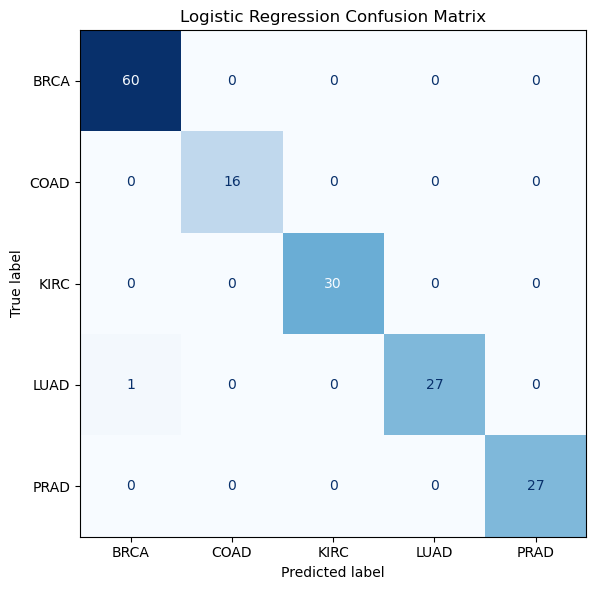

In [15]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=logistic_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

display.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/figures/model_evaluation/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/model_evaluation/logistic_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

## Random Forest

In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = time.time() - start_time

print(
    f"Training Time: {random_forest_training_time:.4f} seconds"
)

Training Time: 0.2628 seconds


In [17]:
random_forest_predictions = random_forest_model.predict(
    X_test
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(
    f"Random Forest Accuracy: {random_forest_accuracy:.4f}"
)

print()

print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

Random Forest Accuracy: 0.9876

              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



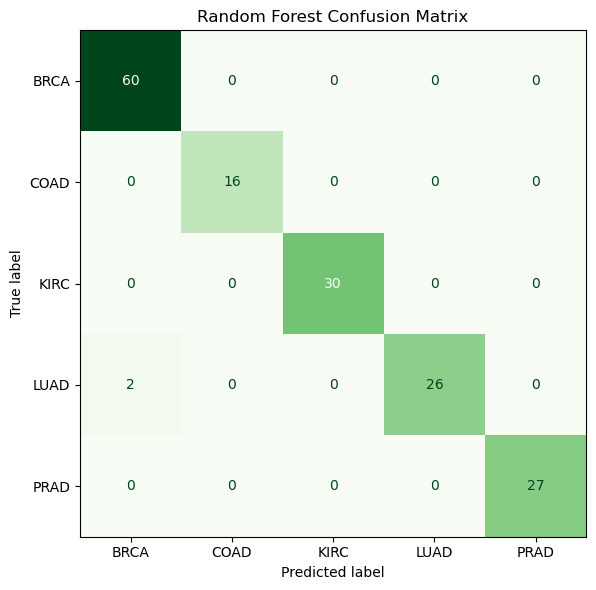

In [18]:
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_cm,
    display_labels=random_forest_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

display.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/figures/model_evaluation/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/model_evaluation/random_forest_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

## Support Vector Machine (Linear Kernel)

In [19]:
svm_model = SVC(
    kernel="linear",
    random_state=42
)

start_time = time.time()

svm_model.fit(
    X_train,
    y_train
)

svm_training_time = time.time() - start_time

print(
    f"Training Time: {svm_training_time:.4f} seconds"
)

Training Time: 0.0093 seconds


In [20]:
svm_predictions = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    f"SVM Accuracy: {svm_accuracy:.4f}"
)

print()

print(
    classification_report(
        y_test,
        svm_predictions
    )
)

SVM Accuracy: 1.0000

              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



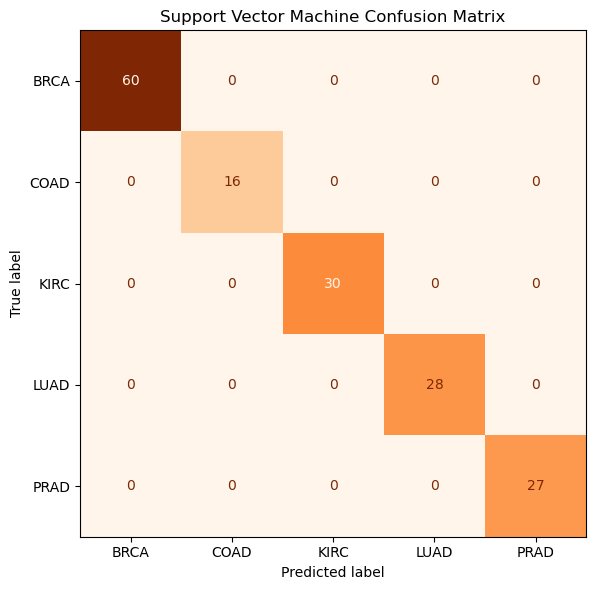

In [21]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=svm_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

display.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=False
)

plt.title("Support Vector Machine Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/figures/model_evaluation/svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/model_evaluation/svm_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

## Model Performance Comparison

In [22]:
comparison_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Support Vector Machine"
        ],
        "Accuracy": [
            logistic_accuracy,
            random_forest_accuracy,
            svm_accuracy
        ],
        "Training Time (s)": [
            logistic_training_time,
            random_forest_training_time,
            svm_training_time
        ]
    }
)

comparison_df

,Model,Accuracy,Training Time (s)
0,Logistic Regression,0.993789,0.070976
1,Random Forest,0.987578,0.262832
2,Support Vector Machine,1.000000,0.009298


In [23]:
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df.reset_index(
    drop=True,
    inplace=True
)

comparison_df

,Model,Accuracy,Training Time (s)
0,Support Vector Machine,1.000000,0.009298
1,Logistic Regression,0.993789,0.070976
2,Random Forest,0.987578,0.262832


## Model Comparison Summary

Three classical machine learning algorithms were evaluated on the selected 250-gene transcriptomic dataset.

- **Support Vector Machine (Linear Kernel)** achieved the highest test-set classification accuracy (100%) among the evaluated models while also demonstrating efficient training performance.

- **Logistic Regression** provided near-perfect predictive performance and served as an interpretable baseline model for transcriptomic cancer classification.

- **Random Forest** demonstrated strong classification performance and provided robustness by capturing complex feature interactions and nonlinear patterns within gene expression data.

Overall, all evaluated classifiers achieved strong predictive performance, suggesting that the selected 250-gene feature subset contains highly discriminative information for distinguishing multiple cancer types.